In [4]:
import models_best_params_defense as M
import pandas as pd
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt

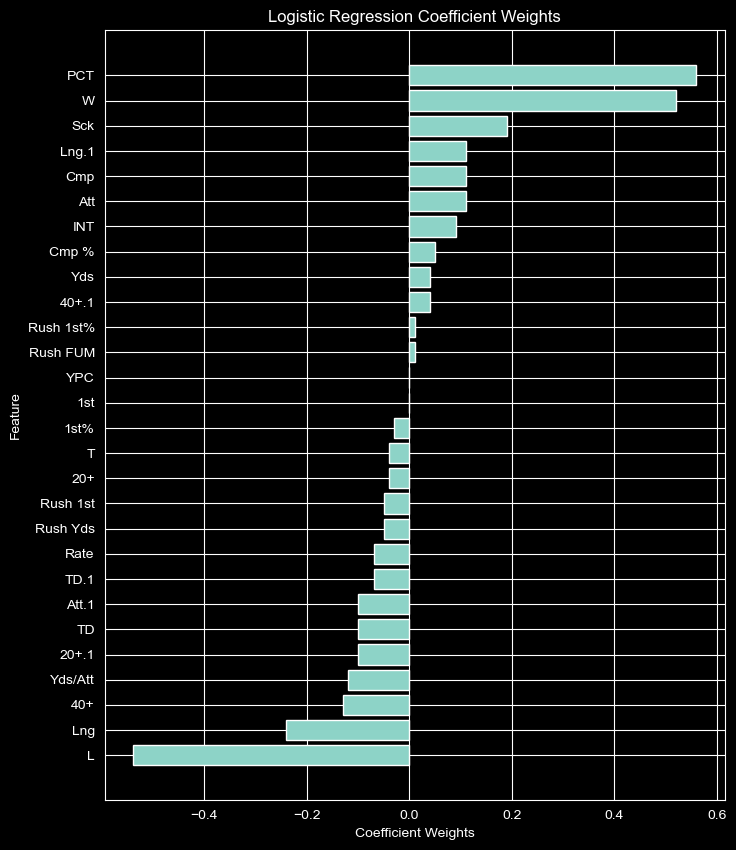

In [5]:
lr_model = M.lr.named_steps['logisticregression']
lr_coefficients = lr_model.coef_[0]

features = pd.DataFrame({'Features': M.X_train.columns,
                         'Coefficients': lr_coefficients}).sort_values(by='Coefficients', ascending=False).round(2)

plt.figure(figsize = (8, 10))
plt.barh(features['Features'], features['Coefficients'])
plt.gca().invert_yaxis()

plt.xlabel('Coefficient Weights')
plt.ylabel('Feature')
plt.title('Logistic Regression Coefficient Weights')

plt.show()

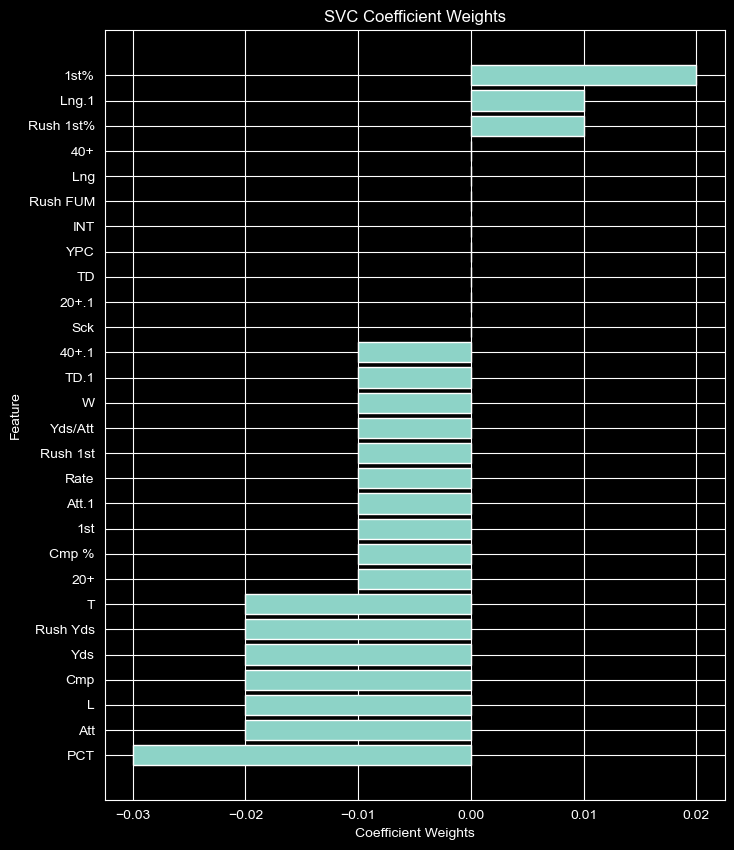

In [6]:
svc_perms = permutation_importance(M.svc, M.X_test, M.y_test)

features = pd.DataFrame({'Features': M.X_test.columns,
                         'Importances': svc_perms.importances_mean}).sort_values(by='Importances', ascending=False).round(2)

plt.figure(figsize = (8, 10))
plt.barh(features['Features'], features['Importances'])
plt.gca().invert_yaxis()

plt.xlabel('Coefficient Weights')
plt.ylabel('Feature')
plt.title('SVC Coefficient Weights')

plt.show()

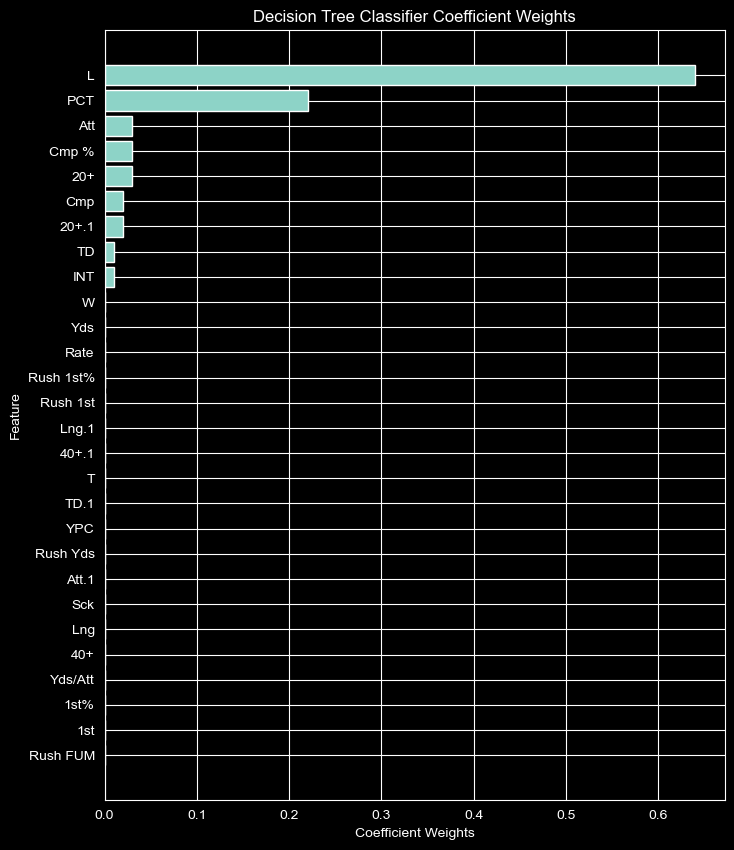

In [7]:
dt_model = M.dt.named_steps['decisiontreeclassifier']
dt_importances = dt_model.feature_importances_

features = pd.DataFrame({'Features': M.X_train.columns,
                         'Importances': dt_importances}).sort_values(by = 'Importances', ascending = False).round(2)

plt.figure(figsize = (8, 10))
plt.barh(features['Features'], features['Importances'])
plt.gca().invert_yaxis()

plt.xlabel('Coefficient Weights')
plt.ylabel('Feature')
plt.title('Decision Tree Classifier Coefficient Weights')

plt.show()

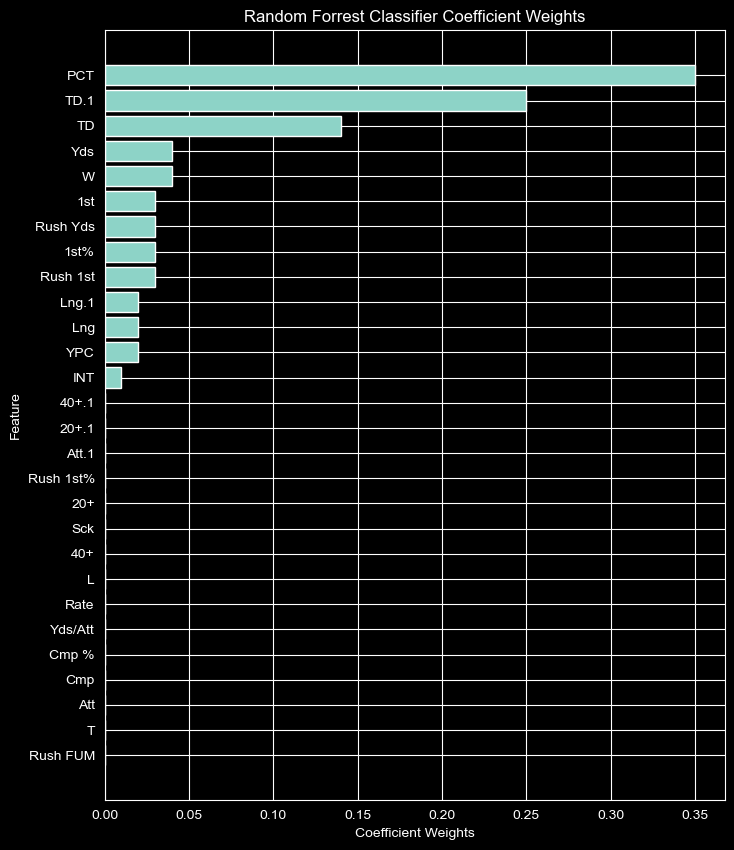

In [8]:
rf_model = M.rf.named_steps['randomforestclassifier']
rf_importances = rf_model.feature_importances_

features = pd.DataFrame({'Features': M.X_train.columns,
                         'Importances': rf_importances}).sort_values(by = 'Importances', ascending = False).round(2)

plt.figure(figsize = (8, 10))
plt.barh(features['Features'], features['Importances'])
plt.gca().invert_yaxis()

plt.xlabel('Coefficient Weights')
plt.ylabel('Feature')
plt.title('Random Forrest Classifier Coefficient Weights')

plt.show()

<Axes: >

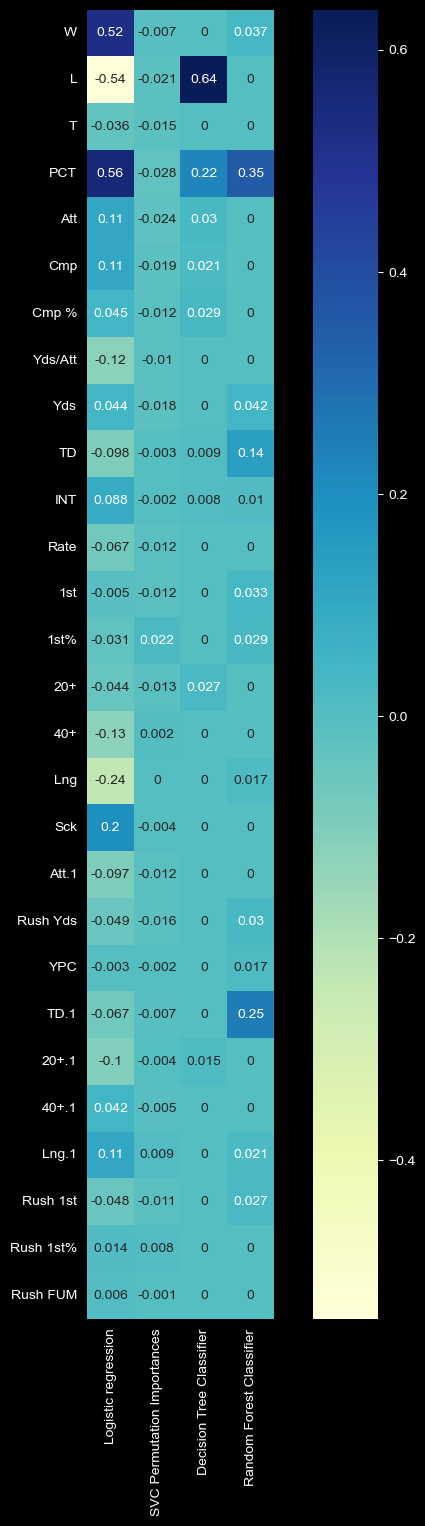

In [9]:
comparison_df = pd.DataFrame({'Logistic regression': lr_coefficients.round(3),
                              'SVC Permutation Importances': svc_perms.importances_mean.round(3),
                              'Decision Tree Classifier': dt_importances.round(3),
                              'Random Forest Classifier': rf_importances.round(3)},
                             index = M.X_train.columns)

vmin = comparison_df.values.min()
vmax = comparison_df.values.max()

plt.figure(figsize = (10, 17))
sns.heatmap(comparison_df, annot = True, square = True, cmap = 'YlGnBu',
            vmin = vmin, vmax = vmax)
